You are working as a Data Analyst for a health insurance company.
The company provides insurance policies to thousands of customers every year. Recently, management observed that insurance claim costs are increasing, but they are not sure which customer factors are driving the cost the most.
🎯 Business Goal
The company wants to:
Identify the key factors that increase medical insurance charges
so they can:
Design risk-based premium plans
Reduce losses caused by high-risk customers
Create fair pricing strategies for customers
Your task is to use Multiple Linear Regression to support this decision.
📁 Dataset Reality (Messy Data)
The dataset contains real-world problems:
Some important columns are categorical (not numeric)
Certain customer attributes are text-based
One column represents geographical regions
Numerical features have very different value ranges
Some variables may be strongly related to each other
The data cannot be used directly for regression.
🧩 Assignment Tasks
- ✅ Task 1 — Business Understanding
- - Identify:
- - The target variable (company’s financial concern)
- - The input variables related to customer risk
- - Explain how your regression model helps the company control rising costs, not just predict them.
- ✅ Task 2 — Data Inspection
- - Explore the dataset and:
- - Separate numeric and categorical columns
- - Identify columns that are not directly usable in regression
- - Report any data quality issues you observe.
- ✅ Task 3 — Data Cleaning & Encoding
- - Convert categorical variables into numeric form.
- - Decide how to handle:
- - Region information
- - Binary attributes like lifestyle indicators
- - Justify each transformation from a business and modeling perspective.
- ✅ Task 4 — Feature Scaling & Comparability
- - Observe differences in value ranges among numeric features.
- - Explain why scaling is important when comparing regression coefficients.
- - Prepare the data so the effect of each variable can be fairly interpreted.
- ⚠️ Task 5 — The Hidden Trap (Multicollinearity)
- - Analyze relationships between independent variables.
- - Identify any highly correlated features (example: age, BMI, and lifestyle habits).
- - Explain:
- - Why multicollinearity is a problem in Multiple Linear Regression
- - How it can confuse business decision-making
- - Take appropriate steps to fix the issue.
- ✅ Task 6 — Build the Multiple Linear Regression Model
- - Build a Multiple Linear Regression model using the prepared dataset.
- - Ensure the model is:
- - Interpretable
- - Stable
- - Suitable for explaining customer cost behavior
- ✅ Task 7 — Model Evaluation
- - Evaluate model performance using appropriate regression metrics.
- - Comment on whether the model is reliable enough to support pricing decisions.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

%matplotlib inline
sns.set(style="whitegrid")

In [6]:
df = pd.read_csv("insurance.csv")   

print(df.head())
print(df.info())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


In [7]:
X = df.drop("charges", axis=1)
y = df["charges"]


In [8]:
X["sex"] = X["sex"].map({"male": 1, "female": 0})
X["smoker"] = X["smoker"].map({"yes": 1, "no": 0})


X = pd.get_dummies(X, columns=["region"], drop_first=True)

print("\nEncoded Features:")
print(X.head())



Encoded Features:
   age  sex     bmi  children  smoker  region_northwest  region_southeast  \
0   19    0  27.900         0       1             False             False   
1   18    1  33.770         1       0             False              True   
2   28    1  33.000         3       0             False              True   
3   33    1  22.705         0       0              True             False   
4   32    1  28.880         0       0              True             False   

   region_southwest  
0              True  
1             False  
2             False  
3             False  
4             False  


In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [10]:
X_vif = sm.add_constant(X_scaled)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print("\nVIF Scores:")
print(vif_data)



VIF Scores:
            Feature       VIF
0             const  1.000000
1               age  1.016822
2               sex  1.008900
3               bmi  1.106630
4          children  1.004011
5            smoker  1.012074
6  region_northwest  1.518823
7  region_southeast  1.652230
8  region_southwest  1.529411


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [12]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [13]:

y_pred = model.predict(X_test)

In [14]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)



Model Performance:
MAE: 4181.194473753654
RMSE: 5796.284659276275
R2 Score: 0.7835929767120722


In [15]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

print("\nModel Coefficients:")
print(coefficients)


Model Coefficients:
            Feature  Coefficient
4            smoker  9544.251089
0               age  3609.149018
2               bmi  2054.885063
3          children   512.478869
1               sex    -9.295337
5  region_northwest  -158.959435
6  region_southeast  -292.759080
7  region_southwest  -347.270359


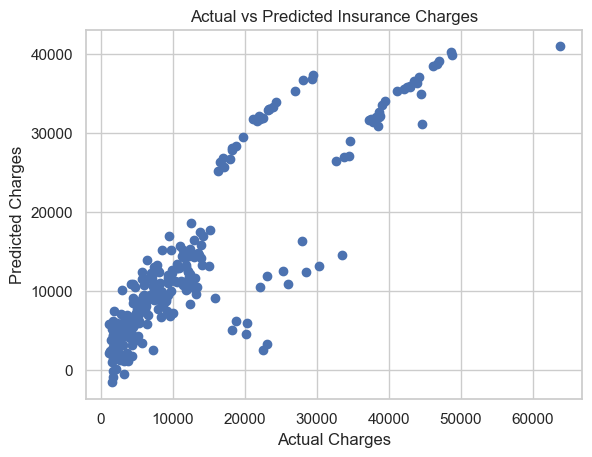

In [16]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")
plt.show()

In [17]:
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Importing the dataset
dataset = pd.read_csv('Position_Salaries.csv')
 
# Independent variable (Position Level)
X = dataset.iloc[:, 1:-1].values
 
# Dependent variable (Salary)
y = dataset.iloc[:, -1].values
 
# Display dataset preview
print("Dataset Preview:")
print(dataset.head())
 

Dataset Preview:
            Position  Level  Salary
0   Business Analyst      1   45000
1  Junior Consultant      2   50000
2  Senior Consultant      3   60000
3            Manager      4   80000
4    Country Manager      5  110000


In [18]:
# Training the Linear Regression model on the whole dataset
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X, y)
 
# Training the Polynomial Regression model on the whole dataset
from sklearn.preprocessing import PolynomialFeatures
poly_reg = PolynomialFeatures(degree = 4)
X_poly = poly_reg.fit_transform(X)
lin_reg_2 = LinearRegression()
lin_reg_2.fit(X_poly, y)
 
print("✅ Models Trained Successfully!")

✅ Models Trained Successfully!


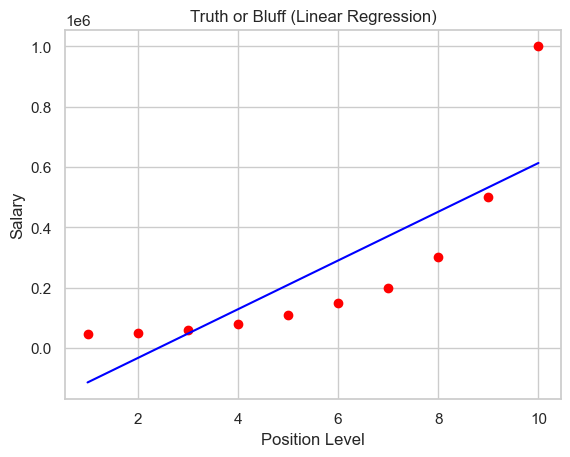

In [19]:
# Visualising the Linear Regression results
plt.scatter(X, y, color = 'red')
plt.plot(X, lin_reg.predict(X), color = 'blue')
plt.title('Truth or Bluff (Linear Regression)')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.show()

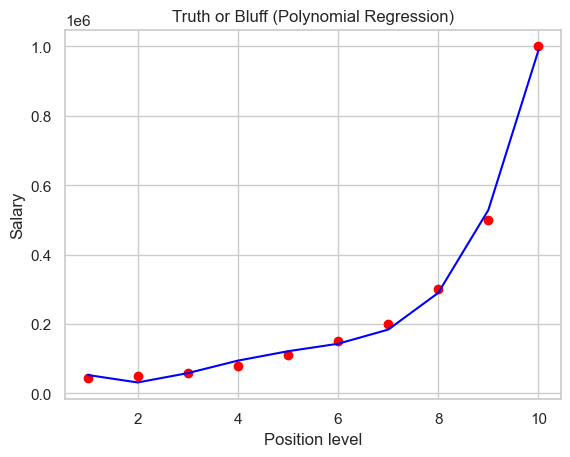

In [20]:
# Visualising the Polynomial Regression results
plt.scatter(X, y, color = 'red')
plt.plot(X, lin_reg_2.predict(poly_reg.fit_transform(X)), color = 'blue')
plt.title('Truth or Bluff (Polynomial Regression)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()
 

C:\Users\Nandini Patel\AppData\Local\Temp\ipykernel_17920\2018302809.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.1)


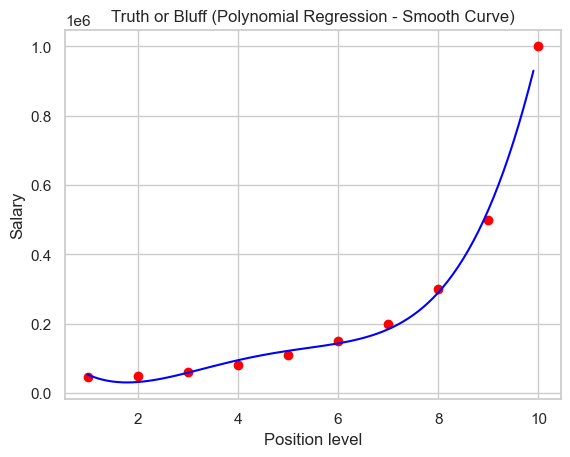

In [21]:
# Visualising the Polynomial Regression results (for higher resolution and smoother curve)
X_grid = np.arange(min(X), max(X), 0.1)
X_grid = X_grid.reshape((len(X_grid), 1))
plt.scatter(X, y, color = 'red')
plt.plot(X_grid, lin_reg_2.predict(poly_reg.fit_transform(X_grid)), color = 'blue')
plt.title('Truth or Bluff (Polynomial Regression - Smooth Curve)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()
 

In [22]:
# Predicting a new result with Linear Regression
linear_prediction = lin_reg.predict([[6.5]])
print("Linear Regression Prediction for Level 6.5:", linear_prediction)

Linear Regression Prediction for Level 6.5: [330378.78787879]


In [23]:
# Predicting a new result with Polynomial Regression
poly_prediction = lin_reg_2.predict(poly_reg.fit_transform([[6.5]]))
print("Polynomial Regression Prediction for Level 6.5:", poly_prediction)

Polynomial Regression Prediction for Level 6.5: [158862.45265153]


### 🧠 Business Scenario
- An automobile company wants to understand how engine size affects the price of a car.
- From past observations, the product team believes:
- For small engines, price increases slowly
- For medium engines, price increases rapidly
- For very large engines, price growth slows down due to luxury saturation
- This indicates that the relationship between engine size and price is not strictly linear.
- You are hired as a Data Analyst to analyze this pattern and build a model that can predict car prices accurately.
 
### 📝 Tasks
- Load the dataset and identify the relevant columns.
- Use:
- Engine size as the input feature
- Car price as the output variable
- Visualize the relationship between engine size and price.
- Build a predictive model to estimate car price based on engine size.
- Predict the price for a car with:
- Engine size = 200
 

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("CarPrice_Assignment.csv")  

print(df.head())
print(df.info())


   car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          front       88.6  ...         130   
1  convertible        rwd          front       88.6  ...         130   
2    hatchback        rwd          front       94.5  ...         152   
3        sedan        fwd          front       99.8  ...         109   
4        sedan        4wd          front       99.4  ...         136   

   fuelsystem  boreratio  stroke compressionratio horsepower  peakrpm citympg  \

In [25]:
X = df[["enginesize"]]   
y = df["price"]          


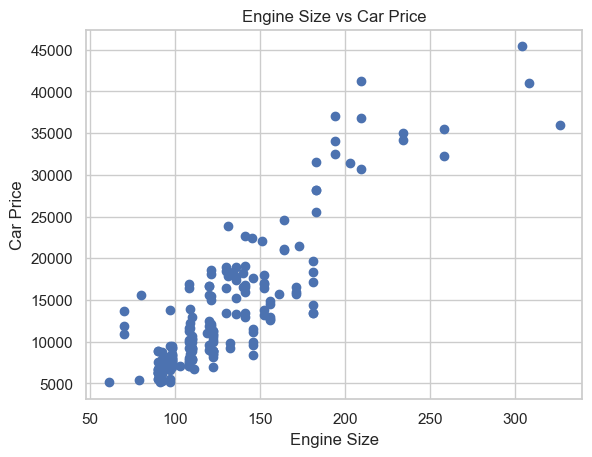

In [26]:
plt.figure()
plt.scatter(X, y)
plt.xlabel("Engine Size")
plt.ylabel("Car Price")
plt.title("Engine Size vs Car Price")
plt.show()


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [28]:
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model = LinearRegression()
model.fit(X_train_poly, y_train)


LinearRegression()

In [29]:
y_pred = model.predict(X_test_poly)


In [30]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)


MAE: 2734.3117108815145
RMSE: 3954.476222207639
R2 Score: 0.8019117595258545


In [31]:
engine_200 = pd.DataFrame({"enginesize": [200]})
engine_200_poly = poly.transform(engine_200)

predicted_price = model.predict(engine_200_poly)
print("Predicted price for engine size 200:", predicted_price[0])


Predicted price for engine size 200: 25565.170876043638


c:\Users\Nandini Patel\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


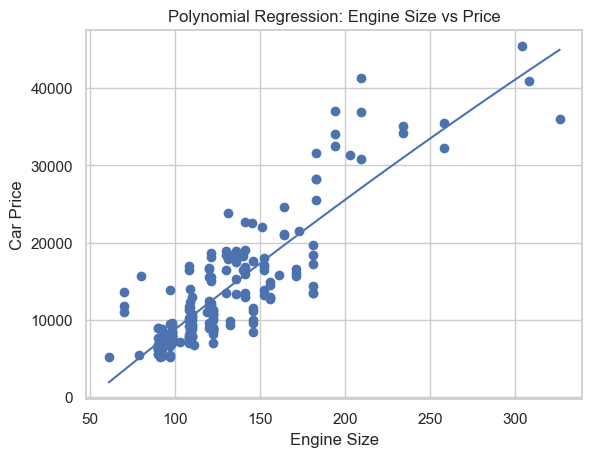

In [32]:
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_range_poly = poly.transform(X_range)
y_range_pred = model.predict(X_range_poly)

plt.figure()
plt.scatter(X, y)
plt.plot(X_range, y_range_pred)
plt.xlabel("Engine Size")
plt.ylabel("Car Price")
plt.title("Polynomial Regression: Engine Size vs Price")
plt.show()


In [33]:
linear_pred = lin_reg.predict([[200]])
print("Linear Regression Price Prediction:", linear_pred)

Linear Regression Price Prediction: [15980424.24242424]


In [34]:
# Predict price for engine size = 200
poly_pred = model.predict(poly.transform([[200]]))
print("Polynomial Regression Price Prediction:", poly_pred[0])


Polynomial Regression Price Prediction: 25565.170876043638


c:\Users\Nandini Patel\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import PolynomialFeatures

# Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X, y)

lin_pred = lin_reg.predict(X)
lin_mae = mean_absolute_error(y, lin_pred)


In [36]:
poly_reg = PolynomialFeatures(degree=3)
X_poly = poly_reg.fit_transform(X)

poly_model = LinearRegression()
poly_model.fit(X_poly, y)

poly_pred = poly_model.predict(X_poly)
poly_mae = mean_absolute_error(y, poly_pred)


In [37]:
print("Linear MAE:", lin_mae)
print("Polynomial MAE:", poly_mae)


Linear MAE: 2815.022353836411
Polynomial MAE: 2692.428908439093


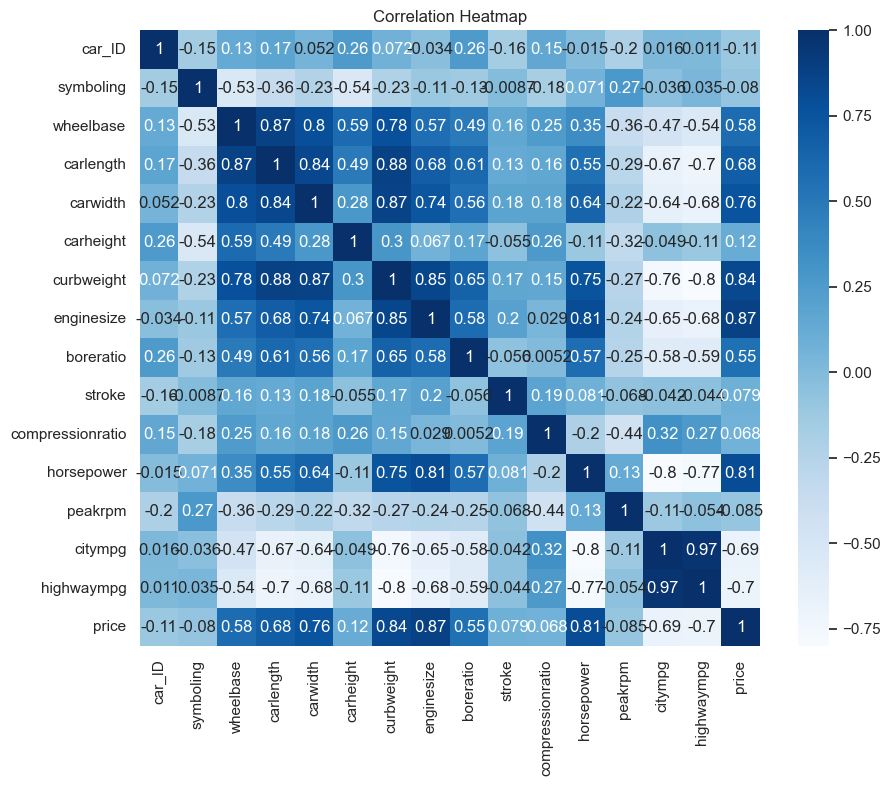

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt


numeric_df = df.select_dtypes(include=['int64', 'float64'])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='Blues')
plt.title("Correlation Heatmap")
plt.show()


#### Insights
Feature    -> Relationship with Price
enginesize -> Strong Positive        
horsepower -> Strong Positive        
curbweight -> Strong Positive        
carwidth   -> Moderate Positive      
citympg    -> Negative               
highwaympg -> Negative               
aspiration -> Positive               
drivewheel -> Positive               
doornumber -> Weak

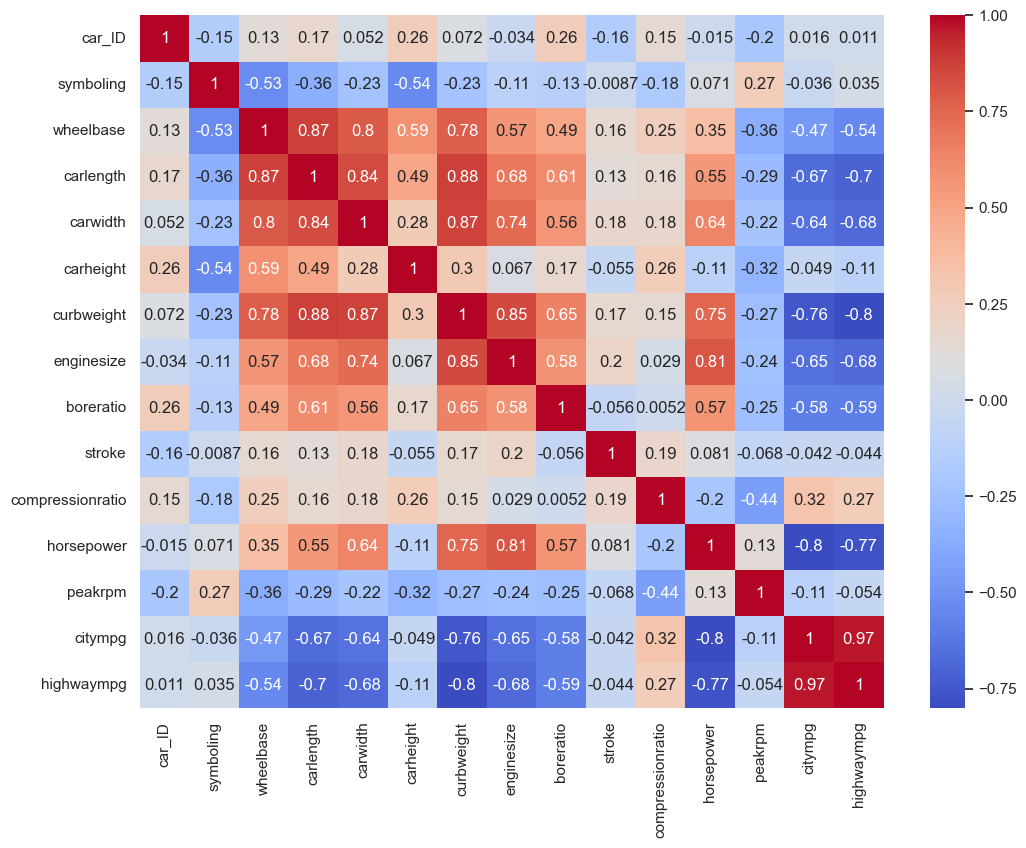

In [39]:
x=df.drop('price',axis=1)
 
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12,9))
sns.heatmap(x.corr(numeric_only=True), annot=True,cmap='coolwarm')
plt.show()

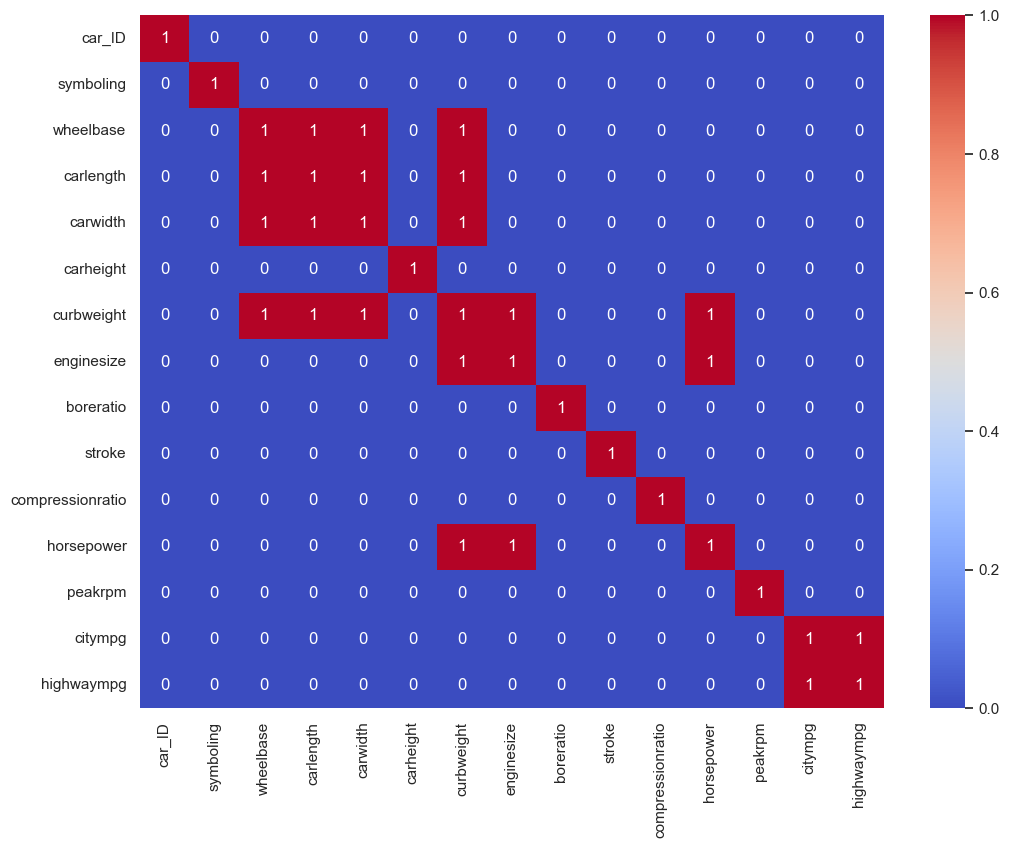

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12,9))
sns.heatmap(x.corr(numeric_only=True)>0.75, annot=True,cmap='coolwarm')
plt.show()

In [41]:
import pandas as pd
import numpy as np

# Select only numeric X features (exclude target)
X_features = df.drop(columns=['price'])
X_features = X_features.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr_matrix = X_features.corr()

# Set threshold
threshold = 0.75

print("Highly Correlated Feature Pairs (> 0.75):\n")

# Loop through upper triangle of correlation matrix
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        corr_value = corr_matrix.iloc[i, j]
        
        if abs(corr_value) > threshold:
            print(
                f"{corr_matrix.columns[i]:<15} "
                f"{corr_matrix.columns[j]:<15} "
                f"{corr_value:.4f}"
            )

Highly Correlated Feature Pairs (> 0.75):

wheelbase       carlength       0.8746
wheelbase       carwidth        0.7951
wheelbase       curbweight      0.7764
carlength       carwidth        0.8411
carlength       curbweight      0.8777
carwidth        curbweight      0.8670
curbweight      enginesize      0.8506
curbweight      horsepower      0.7507
curbweight      citympg         -0.7574
curbweight      highwaympg      -0.7975
enginesize      horsepower      0.8098
horsepower      citympg         -0.8015
horsepower      highwaympg      -0.7705
citympg         highwaympg      0.9713


In [43]:
import pandas as pd
import numpy as np

# Select only numeric X features (exclude target)
X_features = df.drop(columns=['price'])
X_features = X_features.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr_matrix = X_features.corr()

# Set threshold
threshold = 0.7508

print("Highly Correlated Feature Pairs (> 0.75):\n")

# Loop through upper triangle of correlation matrix
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        corr_value = corr_matrix.iloc[i, j]
        
        if corr_value > threshold:
            print(
                f"{corr_matrix.columns[i]:<15} "
                f"{corr_matrix.columns[j]:<15} "
                f"{corr_value:.4f}"
            )

Highly Correlated Feature Pairs (> 0.75):

wheelbase       carlength       0.8746
wheelbase       carwidth        0.7951
wheelbase       curbweight      0.7764
carlength       carwidth        0.8411
carlength       curbweight      0.8777
carwidth        curbweight      0.8670
curbweight      enginesize      0.8506
enginesize      horsepower      0.8098
citympg         highwaympg      0.9713


In [45]:
# Remove highly correlated columns (example: dropping any 6)
cols_to_drop = [
    'wheelbase',
    'carlength',
    'carwidth',
    'curbweight',
    'enginesize',
    'citympg'
]

data_reduced = df.drop(columns=cols_to_drop)

print(data_reduced.columns)

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'carheight',
       'enginetype', 'cylindernumber', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'highwaympg', 'price'],
      dtype='object')


In [46]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Separate features & target
X = data_reduced.drop(columns=['price'])
y = data_reduced['price']

# Convert categorical columns to numeric
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Metrics
print("Train MSE:", mean_squared_error(y_train, y_train_pred))
print("Test MSE :", mean_squared_error(y_test, y_test_pred))
print("Train R2 :", r2_score(y_train, y_train_pred))
print("Test R2  :", r2_score(y_test, y_test_pred))

Train MSE: 372271.7028069961
Test MSE : 362668738.3346265
Train R2 : 0.9937577933888267
Test R2  : -3.593998814520469


In [58]:
from sklearn.linear_model import RidgeCV
 
alphas=np.arange(0.1,10,0.05)

model=RidgeCV(alphas=alphas)
 
model.fit(X_train, y_train)
 

RidgeCV(alphas=array([0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 , 0.55, 0.6 ,
       0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  , 1.05, 1.1 , 1.15,
       1.2 , 1.25, 1.3 , 1.35, 1.4 , 1.45, 1.5 , 1.55, 1.6 , 1.65, 1.7 ,
       1.75, 1.8 , 1.85, 1.9 , 1.95, 2.  , 2.05, 2.1 , 2.15, 2.2 , 2.25,
       2.3 , 2.35, 2.4 , 2.45, 2.5 , 2.55, 2.6 , 2.65, 2.7 , 2.75, 2.8 ,
       2.85, 2.9 , 2.95, 3.  , 3.05, 3.1 , 3.15, 3.2 , 3.25, 3.3 , 3.35,
       3.4 , 3.45, 3.5 , 3.55, 3.6 , 3.65, 3.7 , 3.7...
       5.6 , 5.65, 5.7 , 5.75, 5.8 , 5.85, 5.9 , 5.95, 6.  , 6.05, 6.1 ,
       6.15, 6.2 , 6.25, 6.3 , 6.35, 6.4 , 6.45, 6.5 , 6.55, 6.6 , 6.65,
       6.7 , 6.75, 6.8 , 6.85, 6.9 , 6.95, 7.  , 7.05, 7.1 , 7.15, 7.2 ,
       7.25, 7.3 , 7.35, 7.4 , 7.45, 7.5 , 7.55, 7.6 , 7.65, 7.7 , 7.75,
       7.8 , 7.85, 7.9 , 7.95, 8.  , 8.05, 8.1 , 8.15, 8.2 , 8.25, 8.3 ,
       8.35, 8.4 , 8.45, 8.5 , 8.55, 8.6 , 8.65, 8.7 , 8.75, 8.8 , 8.85,
       8.9 , 8.95, 9.  , 9.05, 9.1 , 9.15, 9.2 , 9.25, 9.3 , 9.35, 9.4 ,
       9.45, 9.5 , 9.55, 9.6 , 9.65, 9.7 , 9.75, 9.8 , 9.85, 9.9 , 9.95]))

In [59]:
from sklearn.linear_model import RidgeCV

import numpy as np

model=RidgeCV(alphas=alphas)

alphas=np.arange(0.1,10,0.05)

model.fit(X_train, y_train)

print("Best alpha:", model.alpha_)

print("best score: ",model.score(X_test,y_test))
 

Best alpha: 0.5500000000000002
best score:  0.8857502114789632


bike rental.csv

descriptive statistics

handle missing values

if error ? in this data handle those values

check distributions numerical categorical data

correlation matrix heatmap draw insights

if you hypothesis testing

encoding (one hot or label)

scaling standard normalization

split data, train Linear regression , polynomial regression lasso ridge
best alpha for lasso ridge , r2score mse rmse mae